# Importing the Required Packages

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Data Preprocessing

## Loading the Dataset

In [3]:
data = pd.read_csv('../Dataset/creditcard.csv')

In [4]:
# Display basic dataset information
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
print(data.describe())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  3.918649e-15  5.682686e-16 -8.761736e-15  2.811118e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean  -1.552103e-15  2.040130e-15 -1.698953e-15 -1.893285e-16 -3.147640e-15   
std    1.380247e+00  1.332271e+00  1.23709

## Handling The Missing Values

In [6]:
# Check for missing values
print(data.isnull().sum())

# Drop rows or impute missing values (if applicable)
data = data.dropna()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


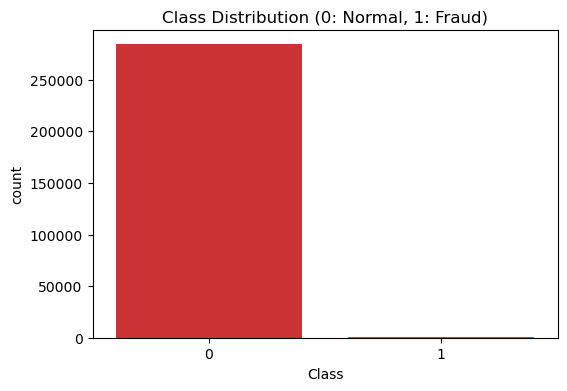

In [7]:
# Plot the class distribution to see the imbalance

plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=data, palette='Set2')
plt.title('Class Distribution (0: Normal, 1: Fraud)')
plt.show()

## Feature Scaling (Normalization)

In [8]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data.drop(['Class'], axis=1))

# Create a new DataFrame with scaled features
scaled_data = pd.DataFrame(scaled_features, columns=data.columns[:-1])
scaled_data['Class'] = data['Class']  # Add the target variable back

## Handling the Imbalance dataset

In [9]:
normal = data[data.Class==0]
fraud = data[data.Class==1]

normal_sample = normal.sample(n=492)
new_dataset = pd.concat([normal_sample, fraud], axis=0)

# Splitting the dataset
X = new_dataset.drop(columns='Class', axis=1)
Y = new_dataset['Class']

x_train_balanced, x_test_balanced, y_train_balanced, y_test_balanced = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

In [10]:
y_test_balanced.value_counts()

0    99
1    98
Name: Class, dtype: int64

### Comparing the mean of Class with Original dataset and Undersampled Dataset

In [11]:
data.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


In [12]:
new_dataset.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,92011.382114,-0.041280,-0.133114,0.083773,-0.011778,0.026905,-0.042771,0.066946,-0.036459,-0.049867,...,-0.041221,0.027717,-0.056724,-0.003600,0.035131,-0.007745,-0.020767,-0.008949,-0.037780,94.422764
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


## Splitting the Data

In [13]:
# Define features and target variable
X = scaled_data.drop(['Class'], axis=1)
y = scaled_data['Class']

# Split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)

# Defining Visualization Functions

## Function for Confusion Matrix Plotting

In [14]:
def plot_confusion_matrix(model, x_test_prediction, y_test, model_name, cmap):
    conf_matrix = confusion_matrix(y_test, x_test_prediction)
    print("Confusion Matrix:")
    plt.figure(figsize=(5, 4))
    sns.heatmap(conf_matrix, annot=True, fmt=" d", cmap=cmap, cbar=True)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

## Function for ROC curve Plotting

In [15]:
def plot_roc_curve(model, x_test, y_test, model_name, color):
    x_test_probability = model.predict_proba(x_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, x_test_probability)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, color=color, lw=1, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
    plt.xlim([-0.05, 1.05])
    plt.ylim([-0.05, 1.05])
    plt.xlabel('False Positive Rate', fontsize=10)
    plt.ylabel('True Positive Rate', fontsize=10)
    plt.title('Receiver Operating Characteristic', fontsize=10)
    plt.legend(loc="lower right",fontsize=10)
    plt.show()

# Model Training and Evaluation

## Logistic Regression Classifier

In [16]:
# Model intialization and training

lr = LogisticRegression(max_iter=1000)
lr.fit(x_train_balanced, y_train_balanced)

LogisticRegression(max_iter=1000)

In [17]:
# Model prediction with training data

lr_train_prediction = lr.predict(x_train_balanced)
lr_train_accuracy = accuracy_score(lr_train_prediction, y_train_balanced)
print("Accuracy score of training data: ", lr_train_accuracy)

Accuracy score of training data:  0.9390088945362135


In [18]:
# Model prediction with test data

lr_test_prediction = lr.predict(x_test_balanced)
lr_accuracy = accuracy_score(lr_test_prediction, y_test_balanced)
print("Accuracy score of test data: ", lr_accuracy)

Accuracy score of test data:  0.9390862944162437


Confusion Matrix:


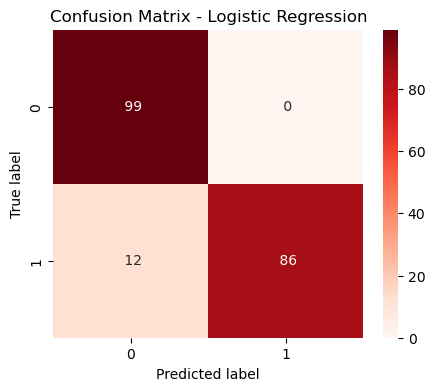

In [19]:
plot_confusion_matrix(lr, lr_test_prediction, y_test_balanced, "Logistic Regression", "Reds")

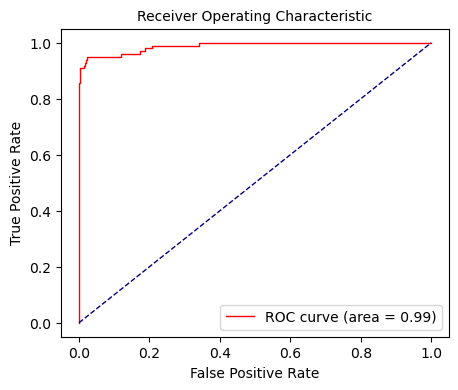

In [20]:
plot_roc_curve(lr, x_test, y_test, "Logistic Regression", "red")

In [21]:
# Precision Score

lr_precision = precision_score(y_test_balanced, lr_test_prediction)
print(lr_precision)

1.0


In [22]:
# Recall score

lr_recall = recall_score(y_test_balanced, lr_test_prediction)
print(lr_recall)

0.8775510204081632


In [23]:
lr_f1_score = f1_score(y_test_balanced, lr_test_prediction)
lr_f1_score

0.9347826086956522

In [24]:
print("Classification Report:\n", classification_report(y_test_balanced, lr_test_prediction))

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94        99
           1       1.00      0.88      0.93        98

    accuracy                           0.94       197
   macro avg       0.95      0.94      0.94       197
weighted avg       0.95      0.94      0.94       197



## Decision Tree Classifier

In [25]:
# Model intialization and training

dt = DecisionTreeClassifier(criterion="entropy", random_state=0)
dt.fit(x_train_balanced, y_train_balanced)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [26]:
# Model prediction with training data

dt_train_prediction = dt.predict(x_train_balanced)
dt_train_accuracy = accuracy_score(dt_train_prediction, y_train_balanced)
print("Accuracy score of training data: ", dt_train_accuracy)

Accuracy score of training data:  1.0


In [27]:
# Model prediction with test data

dt_test_prediction = dt.predict(x_test_balanced)
dt_accuracy = accuracy_score(dt_test_prediction, y_test_balanced)
print("Accuracy score of test data: ", dt_accuracy)

Accuracy score of test data:  0.8984771573604061


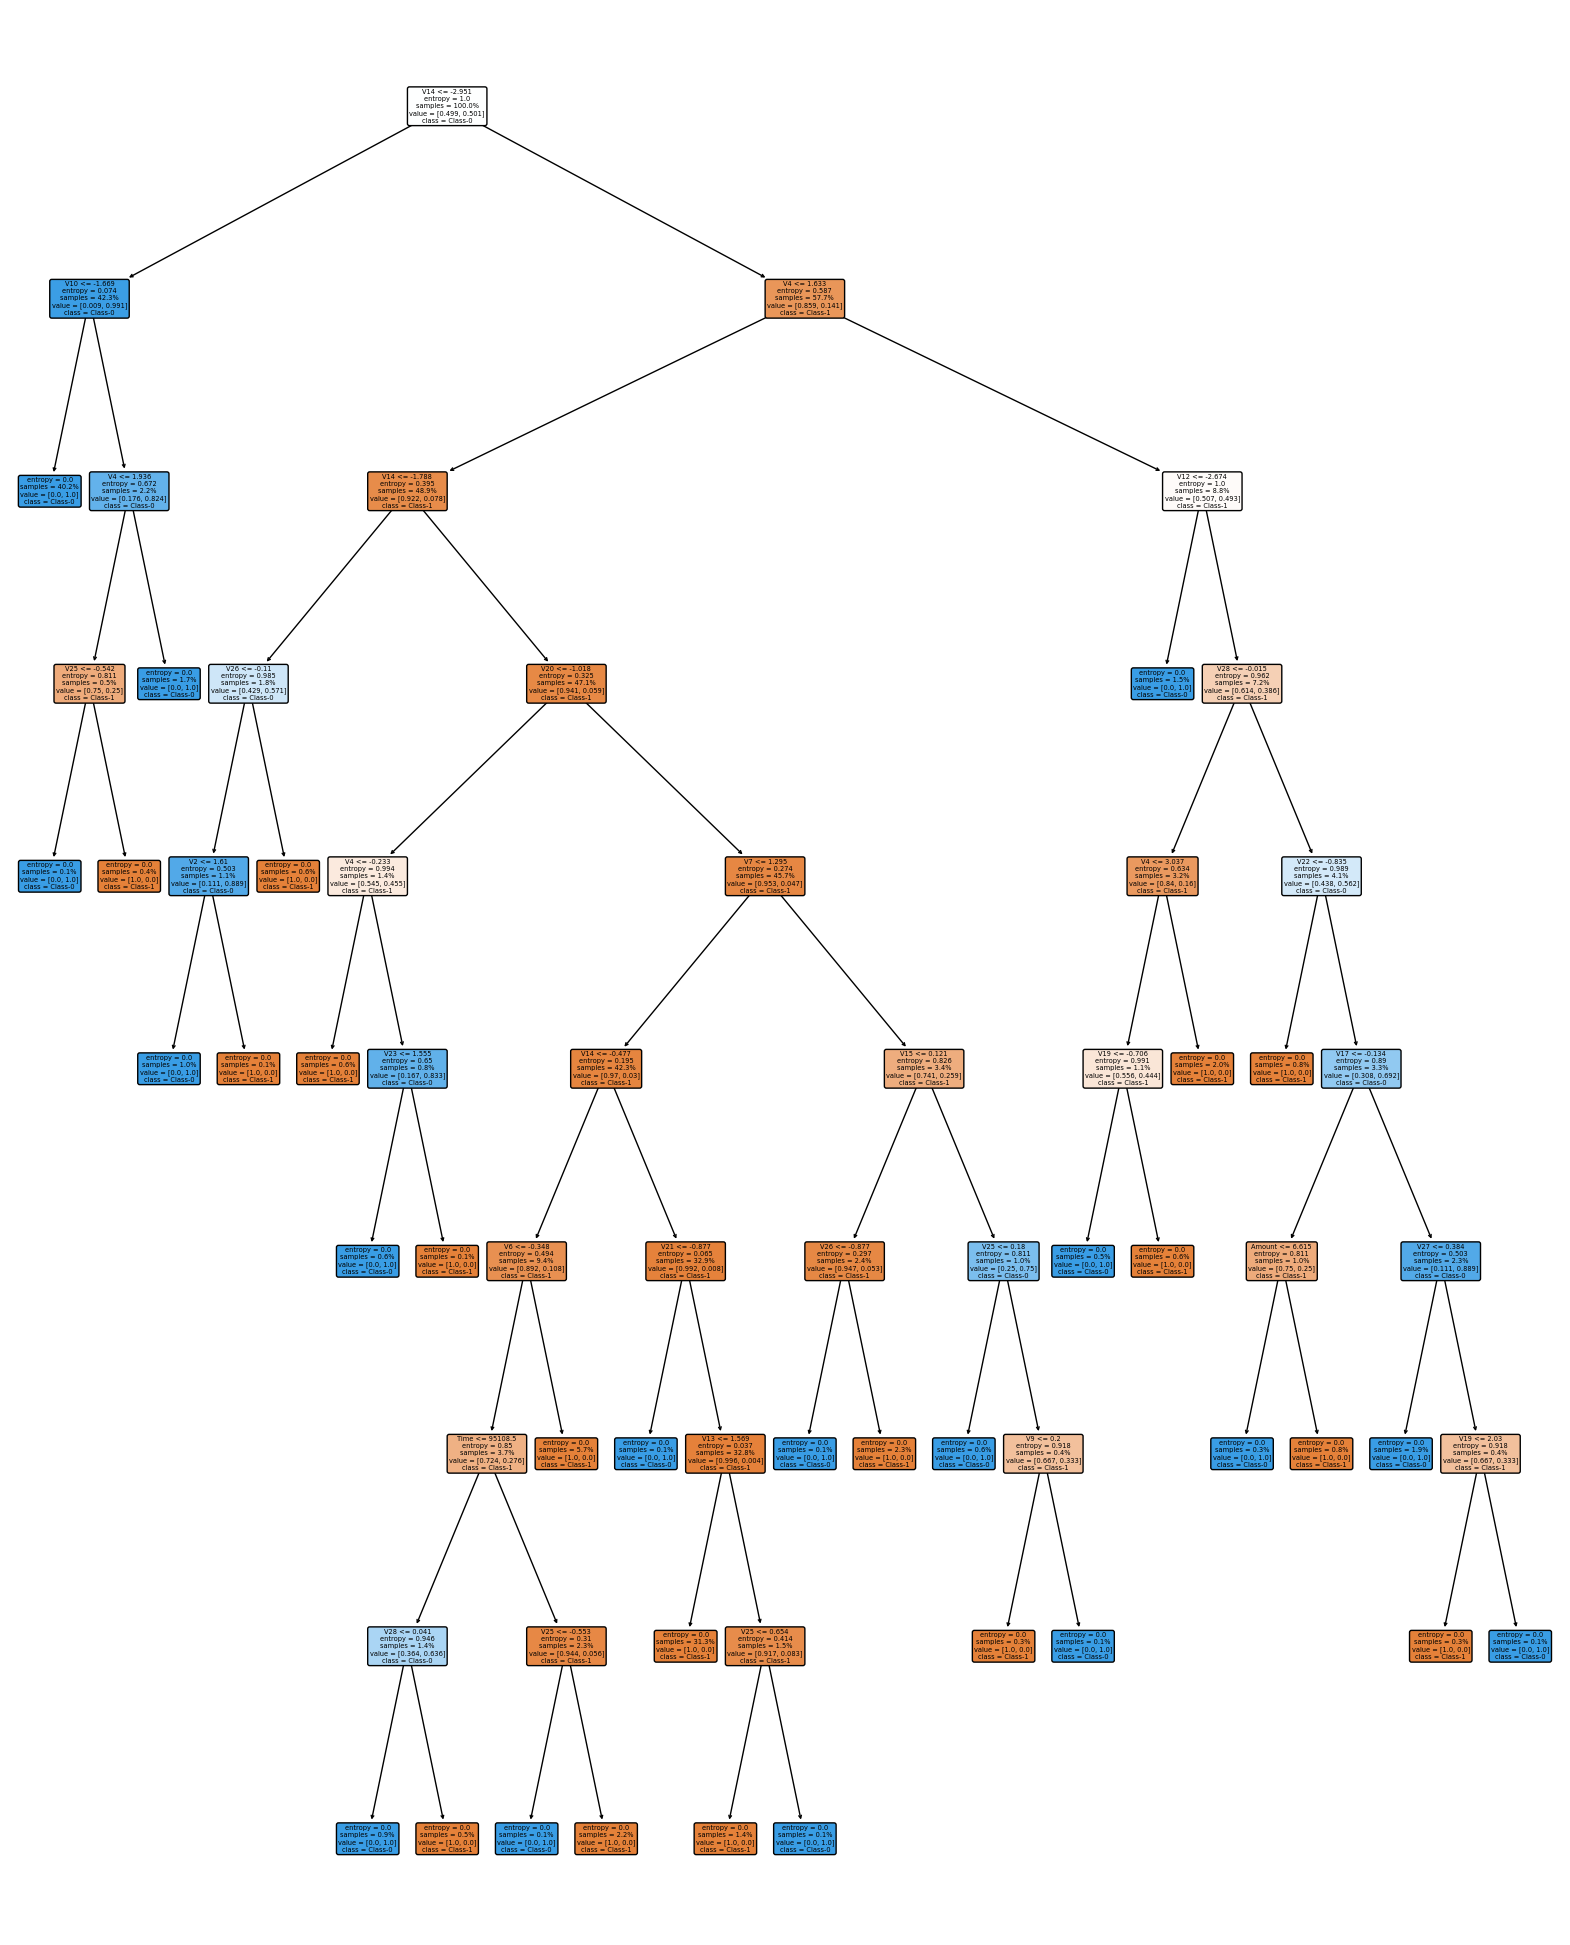

In [28]:
plt.figure(figsize=(20, 25))
tree.plot_tree(dt, feature_names=X.columns, class_names=['Class-1', 'Class-0'], rounded=True, filled=True, proportion=True)
plt.show()

Confusion Matrix:


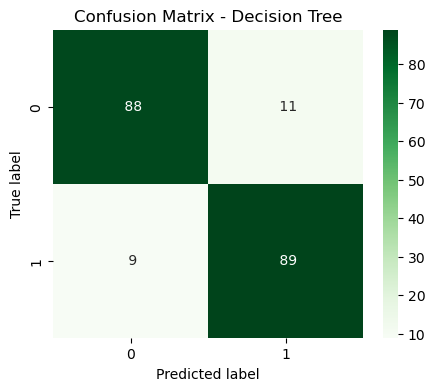

In [29]:
plot_confusion_matrix(dt, dt_test_prediction, y_test_balanced, "Decision Tree", "Greens")

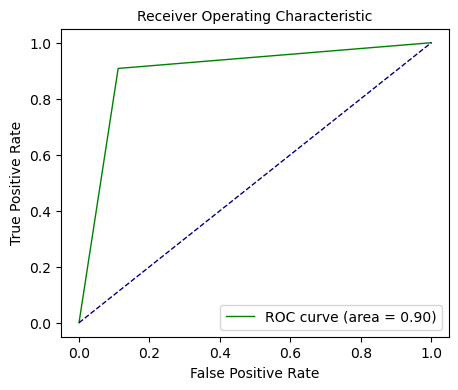

In [30]:
plot_roc_curve(dt, x_test_balanced, y_test_balanced, "Decision Tree", "Green")

In [31]:
# Precision Score

dt_precision = precision_score(y_test_balanced, dt_test_prediction)
print(dt_precision)

0.89


In [32]:
# Recall score

dt_recall = recall_score(y_test_balanced, dt_test_prediction)
print(dt_recall)

0.9081632653061225


In [33]:
dt_f1_score = f1_score(y_test_balanced, dt_test_prediction)
dt_f1_score

0.8989898989898989

In [34]:
print("Classification Report:\n", classification_report(y_test_balanced, dt_test_prediction))

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.89      0.90        99
           1       0.89      0.91      0.90        98

    accuracy                           0.90       197
   macro avg       0.90      0.90      0.90       197
weighted avg       0.90      0.90      0.90       197



## Random Forest Classifier

In [ ]:
# Model intialization and training

rf = RandomForestClassifier(n_estimators=20, criterion='entropy', random_state=0, max_depth=10)
rf.fit(x_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=10, n_estimators=20,
                       random_state=0)

In [36]:
# Model prediction with training data

rf_train_prediction = rf.predict(x_train)
rf_train_accuracy = accuracy_score(rf_train_prediction, y_train)
print("Accuracy score of training data: ", rf_train_accuracy)

Accuracy score of training data:  0.9997191072878492


In [37]:
# Model prediction with test data

rf_test_prediction = rf.predict(x_test)
rf_accuracy = accuracy_score(rf_test_prediction, y_test)
print("Accuracy score of test data: ", rf_accuracy)

Accuracy score of test data:  0.9995786664794073


Confusion Matrix:


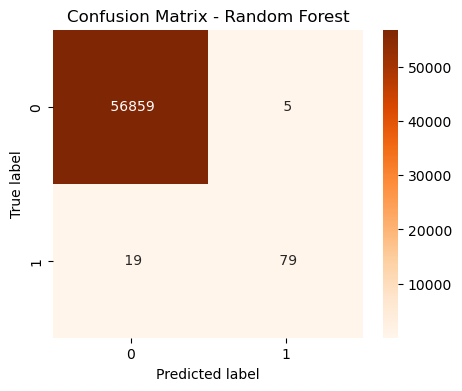

In [38]:
plot_confusion_matrix(rf, rf_test_prediction, y_test, "Random Forest", "Oranges")

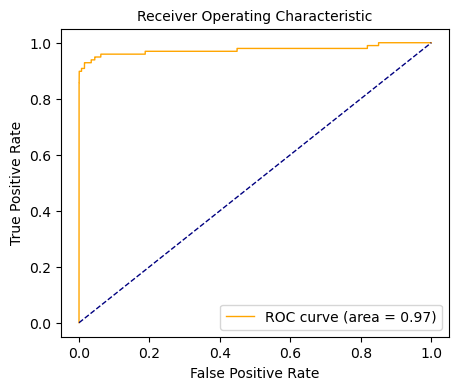

In [39]:
plot_roc_curve(rf, x_test, y_test, "Random Forest", "Orange")

In [40]:
# Precision Score

rf_precision = precision_score(y_test, rf_test_prediction)
print(rf_precision)

0.9404761904761905


In [41]:
# Recall score

rf_recall = recall_score(y_test, rf_test_prediction)
print(rf_recall)

0.8061224489795918


In [42]:
rf_f1_score = f1_score(y_test, rf_test_prediction)
rf_f1_score

0.8681318681318683

In [43]:
print("Classification Report:\n", classification_report(y_test, rf_test_prediction))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.81      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962



## Gradient Boosting Classifier

In [44]:
# Model intialization and training

gb = GradientBoostingClassifier()
gb.fit(x_train, y_train)

GradientBoostingClassifier()

In [45]:
# Model prediction with training data

gb_train_prediction = gb.predict(x_train)
gb_train_accuracy = accuracy_score(gb_train_prediction, y_train)
print("Accuracy score of training data: ", gb_train_accuracy)

Accuracy score of training data:  0.9996927735960851


In [46]:
# Model prediction with test data

gb_test_prediction = gb.predict(x_test)
gb_accuracy = accuracy_score(gb_test_prediction, y_test)
print("Accuracy score of test data: ", gb_accuracy)

Accuracy score of test data:  0.9993504441557529


Confusion Matrix:


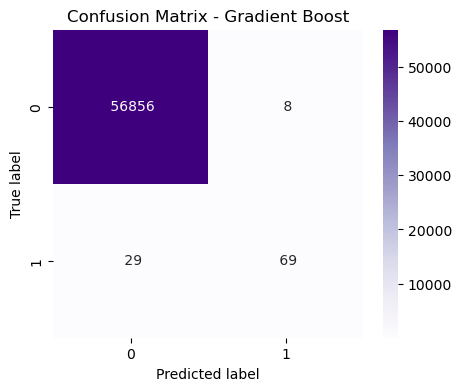

In [47]:
plot_confusion_matrix(gb, gb_test_prediction, y_test, "Gradient Boost", "Purples")

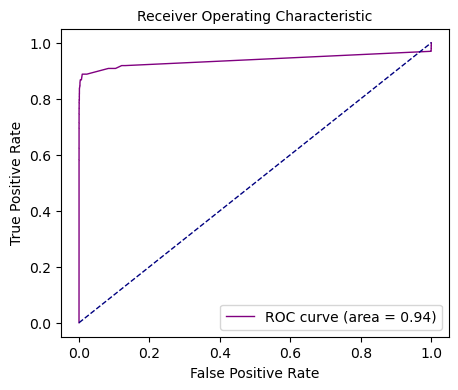

In [48]:
plot_roc_curve(gb, x_test, y_test, "Gradient Boosting", "Purple")

In [49]:
# Precision Score

gb_precision = precision_score(y_test, gb_test_prediction)
print(gb_precision)

0.8961038961038961


In [50]:
# Recall score

gb_recall = recall_score(y_test, gb_test_prediction)
print(gb_recall)

0.7040816326530612


In [51]:
gb_f1_score = f1_score(y_test, gb_test_prediction)
gb_f1_score

0.7885714285714286

In [52]:
print("Classification Report:\n", classification_report(y_test, gb_test_prediction))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.90      0.70      0.79        98

    accuracy                           1.00     56962
   macro avg       0.95      0.85      0.89     56962
weighted avg       1.00      1.00      1.00     56962



## Comparing the Models based on Accuracy, Precision, Recall

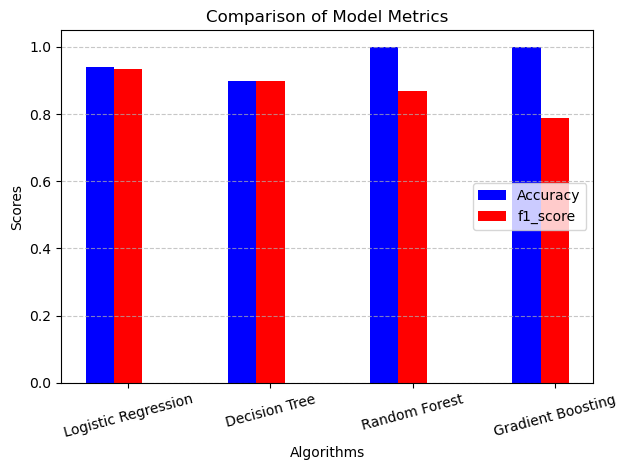

In [53]:
import matplotlib.pyplot as plt
import numpy as np

# Sample scores (replace with your actual values)
lr_scores = [lr_accuracy, lr_f1_score]
dt_scores = [dt_accuracy, dt_f1_score]
rf_scores = [rf_accuracy, rf_f1_score]
gb_scores = [gb_accuracy, gb_f1_score]

# Combine scores into a matrix for easy plotting
scores = np.array([lr_scores, dt_scores, rf_scores, gb_scores])

# Bar width and positions
bar_width = 0.20
indices = np.arange(len(scores))

# Create bars for each metric
plt.bar(indices, scores[:, 0], bar_width, label='Accuracy', color='lb')
plt.bar(indices + bar_width, scores[:, 1], bar_width, label='f1_score', color='r')
#plt.bar(indices + 2 * bar_width, scores[:, 2], bar_width, label='Recall', color='y')

# Add labels and formatting
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.xticks(indices + bar_width, ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'], rotation=15)
plt.legend(loc="center right")
plt.xlabel("Algorithms")
plt.ylabel("Scores")
plt.title("Comparison of Model Metrics")

# Display the plot
plt.tight_layout()
plt.show()

